In [1]:
import numpy as np

In [2]:
# vectors
ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])
print("Vectors: ")
print(ket0 / 2 + ket1 / 2)

Vectors: 
[[0.5]
 [0.5]]


In [3]:
# arrays --- operations
M1 = np.array([[1, 1], [0, 0]])
M2 = np.array([[1, 0], [0, 1]])
M = M1 / 2 + M2 / 2
print("\nArrays (operations): ")
print(M)


Arrays (operations): 
[[1.  0.5]
 [0.  0.5]]


In [4]:
# matrix & matrix-vector multiplication
print("\nMatrix & Matrix-Vector Multiplication")
print(M1 @ ket1)
print(M1 @ M2)
print(M @ M)



Matrix & Matrix-Vector Multiplication
[[1]
 [0]]
[[1 1]
 [0 0]]
[[1.   0.75]
 [0.   0.25]]


In [5]:
from qiskit.visualization import array_to_latex
display(array_to_latex(M1 @ ket1))
display(array_to_latex(M1 @ M2))
display(array_to_latex(M @ M))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [6]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

# state vectors
u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])

In [7]:
# displaying state vectors

display(u.draw("text"))
display(u.draw("latex"))
print(u.draw("latex_source")) # don't use display, print is more reliable

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


In [8]:
display(u.is_valid())
display(w.is_valid())

True

False

In [9]:
display(v.draw("latex"))

<IPython.core.display.Latex object>

In [10]:
# measuring state vector
# recall: state changes after measurement!

outcome, state = v.measure()
print(f"Measured: {outcome}")
print("Post-measurement state: ")
display(state.draw("latex"))

# .measure() will throw error if state vector isn't valid

Measured: 1
Post-measurement state: 


<IPython.core.display.Latex object>

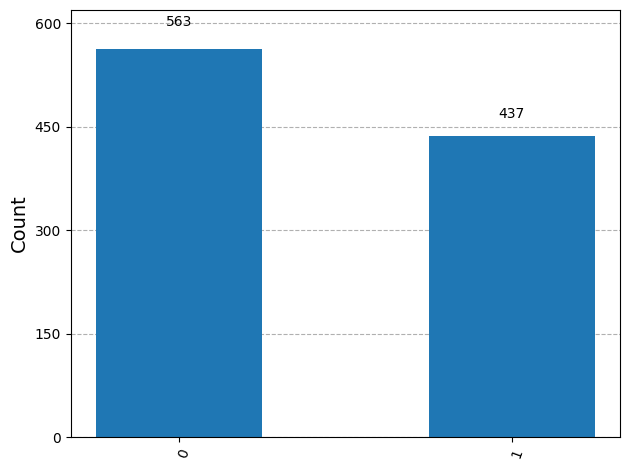

In [11]:
# sample counts -- allows for simulation of any number of measurements on system
# plot_historgram -- visualizes result from sample_counts

from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)

In [12]:
from qiskit.quantum_info import Operator

# performing operators
Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

display(T.draw("latex"))

<IPython.core.display.Latex object>

In [13]:
# applying unitary operation to state vector
# evolve method

v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

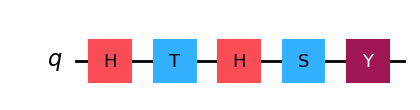

In [ ]:
from qiskit import QuantumCircuit

# playing with quantum circuits

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl")) # mpl for matplotlib

In [15]:
# getting the unitary matrix corresponding to circuit

display(Operator.from_circuit(circuit).draw("latex"))

<IPython.core.display.Latex object>

In [16]:
# running a state vector though the sequence of operations from circuit

ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

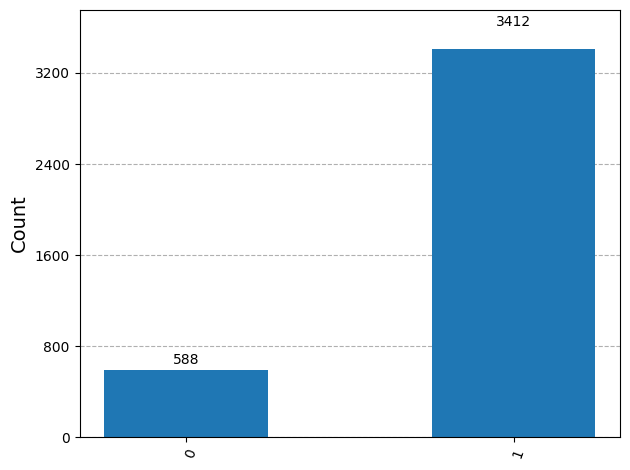

In [17]:
statistics = v.sample_counts(4000)
display(plot_histogram(statistics))